![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [2]:
import warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación librerías
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [4]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


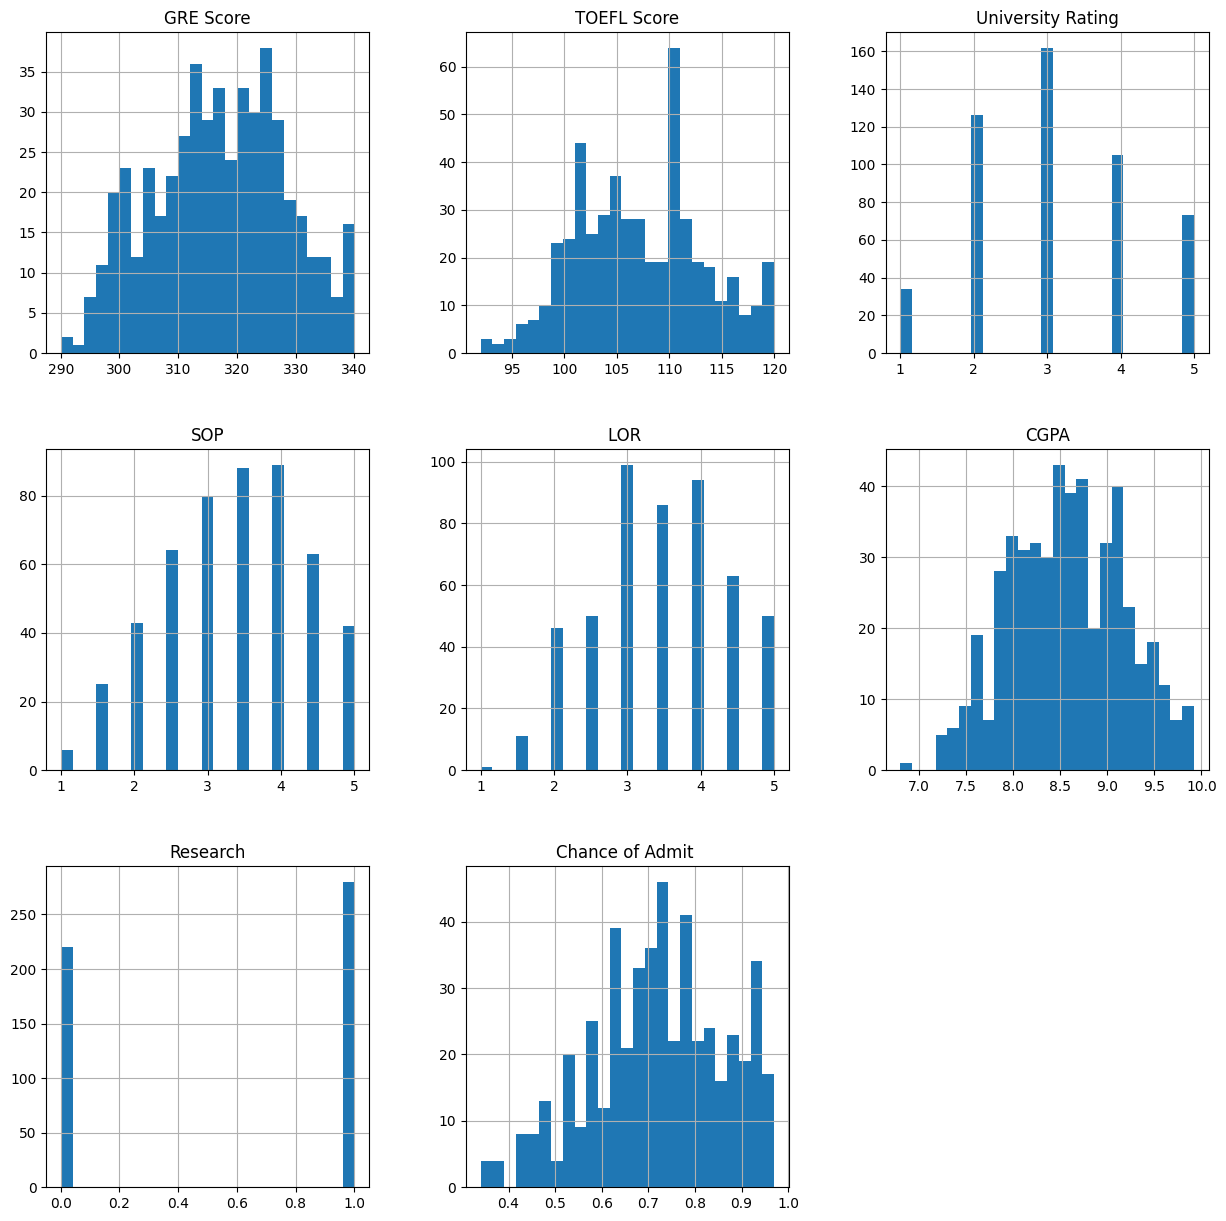

In [5]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [6]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [7]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
X_train, X_test , Y_train, Y_test = train_test_split(X,Y, test_size=0.3 ,random_state=22)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [8]:
# Celda 1
from sklearn.preprocessing import StandardScaler
# Importación librerías
from keras.models import Sequential
from keras.layers import Dense, Activation
from livelossplot import PlotLossesKeras
from keras import backend as K
import keras.optimizers as opts
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Use different variable names to avoid overwriting X_train, X_test, Y_train, Y_test
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

# Definición de la función StandardScaler
scaler = StandardScaler()
scaler.fit(X)

# Transformación de los set de entrenamiento y test
# Keep X_train and X_test as DataFrames
X_train_scaled = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
X_test_scaled = pd.DataFrame(data=scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

# Convert to NumPy arrays if needed for your model
X_train = np.array(X_train_scaled)
Y_train = np.array(yTrain)

X_test = np.array(X_test_scaled)
Y_test = np.array(yTest)

# Get the number of output variables (should be 1 in this case)
output_var = 1  # Y_train is a 1D array, so it has only one output variable
print(output_var, ' output variables')

1  output variables


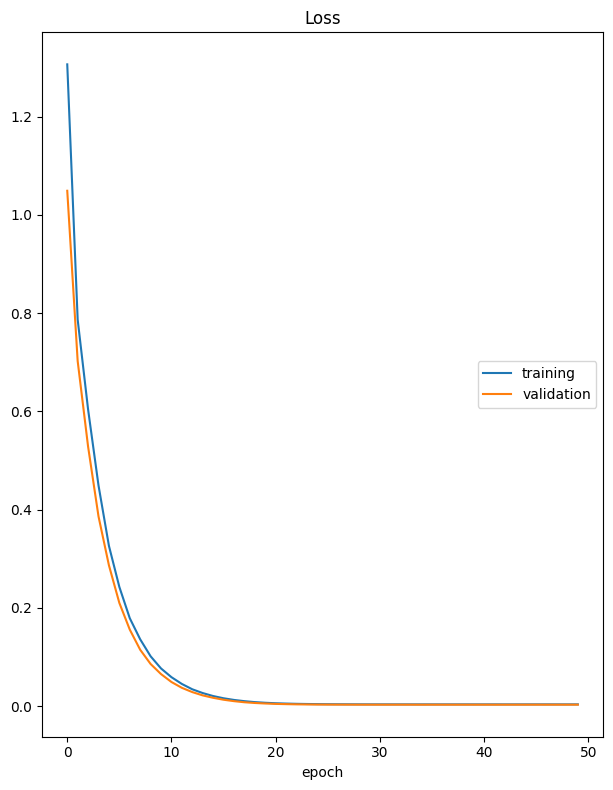

Loss
	training         	 (min:    0.004, max:    1.306, cur:    0.004)
	validation       	 (min:    0.003, max:    1.049, cur:    0.003)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0035 - val_loss: 0.0031
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Evaluación del modelo:
Error Absoluto Medio (MAE): 0.0409
Error Cuadrático Medio (MSE): 0.0031


In [9]:
# Definición de dimensiones de entrada, varaibles predictoras
dims = X_train.shape[1]
print(dims, 'input variables')

K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()
# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model.add(Dense(output_var, input_shape=(dims,)))

# Impresión de la arquitectura de la red neuronal
print(model.summary())

# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# Entrenamiento de la red neuronal con 50 épocas
model.fit(X_train, Y_train,
          verbose=1,
          epochs=50,
          validation_data=(X_test, Y_test),
          callbacks=[PlotLossesKeras()])


# Predicciones del modelo
predictions_modelo1  = model.predict(X_test)

# Cálculo de métricas
mae_modelo1  = mean_absolute_error(Y_test, predictions_modelo1 )
mse_modelo1 = mean_squared_error(Y_test, predictions_modelo1 )

print(f'\nEvaluación del modelo:')
print(f'Error Absoluto Medio (MAE): {mae_modelo1:.4f}')
print(f'Error Cuadrático Medio (MSE): {mse_modelo1:.4f}')

**Análisis**

Explicación del código: Se construye una red neuroanl de una sola capa utlizando Keras, con el ocbjetivo de predecir la porb de admisión, así que para cumplir el objetivo, fue necesario el pre procesamiento de datos separando las variables predictorasm se escalaron usando StandardScaler para luego dividir en datos de entrenamiento y prueba. Se define la arquietectura del modelo como una red secuencial con una única capa.

EL modelo fue compilado utilizando el optimizador ADAM con una tasa de aprendizaje 0.01 y se entrenó durante 50 epocas, utilizando MSE como función de pérdida. Se usó *PlotLossesKeras* para la visual de de evolución de pérdidas, la cuál demuestra un buen ajuste sin presencia de sobreajuste evidente. La pérdida del modelo se estabilizó alrededor de 0.0033 (training) y 0.0032 (validación).

Se obtuvo MAE de 0.0412 y MSE 0.0032. Lo que indicia que el modelo comete errrores peomedio alrededor de 4 puntos porcentuales en las predicciones.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [10]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras import backend as K
from sklearn.metrics import mean_absolute_error, mean_squared_error
from livelossplot import PlotLossesKeras

# Limpiar sesión previa
K.clear_session()

# Definir red neuronal multicapa
model = Sequential()

# Primera capa oculta: 32 neuronas, activación ReLU
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Segunda capa oculta: 16 neuronas, activación ReLU
model.add(Dense(16, activation='relu'))

# Capa de salida: 1 neurona (regresión), sin activación
model.add(Dense(1))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

None


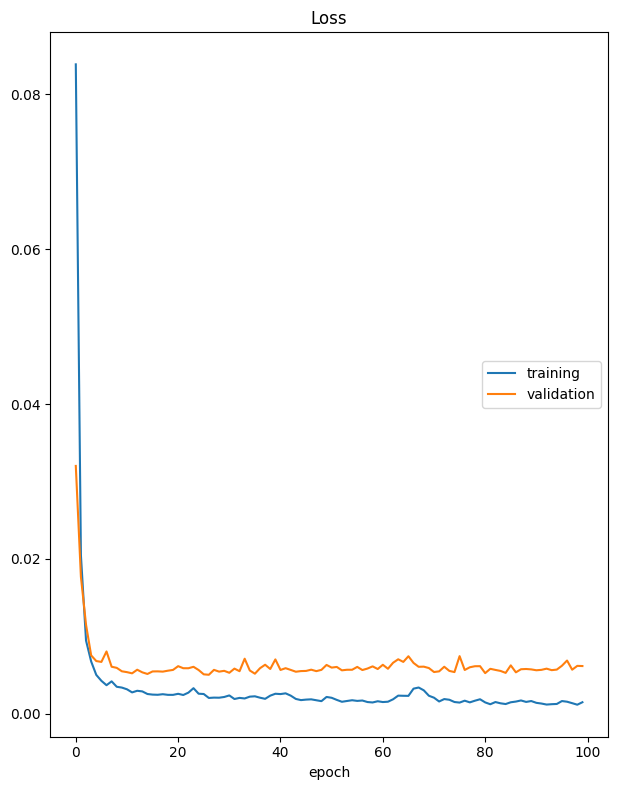

Loss
	training         	 (min:    0.001, max:    0.084, cur:    0.001)
	validation       	 (min:    0.005, max:    0.032, cur:    0.006)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - val_loss: 0.0062
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Evaluación del modelo multicapa:
Error Absoluto Medio (MAE): 0.0617
Error Cuadrático Medio (MSE): 0.0062


In [11]:
# Compilar modelo
# Se usa Adam (más eficiente que SGD) y MSE como pérdida (regresión)
model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

# Entrenar modelo
history = model.fit(
    X_train, Y_train,
    epochs=100,
    validation_data=(X_test, Y_test),
    verbose=1,
    callbacks=[PlotLossesKeras()]
)

# Evaluar desempeño
predictions_modelo2 = model.predict(X_test)
mae_modelo2 = mean_absolute_error(Y_test, predictions_modelo2)
mse_modelo2 = mean_squared_error(Y_test, predictions_modelo2)

print(f'\nEvaluación del modelo multicapa:')
print(f'Error Absoluto Medio (MAE): {mae_modelo2:.4f}')
print(f'Error Cuadrático Medio (MSE): {mse_modelo2:.4f}')

**Análisis**
Se realiza un modelo de red neuronal multicapa, con dos capas ocultas, la primera con 32 y la segunda con 16 neuronas, ambas con activación ReLU, la capa de salida se mantiene con una sola neurona y activación lineal. Se entrena con 100 epocas con validación sobre el conjunto de pruebas.
El valor final de la pérdida en entrenamiento fue de 0.001, mientras que en validación fue de 0.007, lo que sugiere que el modelo logró aprender correctamente sin memorizar en exceso los datos

Se obtiene MAE de 0.0625 y MSE de 0.0069, lo que indica que en promedio se equivoca en 6.25 psuntos porcentuales, a pesar de que un modelo es más complejo, se obtiene un menor rendimiento que el punto 1. Una red más compleja no garantiza una mejor generalización.

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [12]:
# Celda 3
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras import backend as K
from sklearn.metrics import mean_absolute_error, mean_squared_error
from livelossplot import PlotLossesKeras

# Limpiar sesión previa
K.clear_session()

# Red neuronal multicapa con Dropout
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))  # 30% de los nodos desactivados en cada paso

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

# Capa de salida
model.add(Dense(1))  # No se usa activación para regresión

# Imprimir resumen
print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,265 (169.00 KB)

 Trainable params: 43,265 (169.00 KB)

 Non-trainable params: 0 (0.00 B)

None


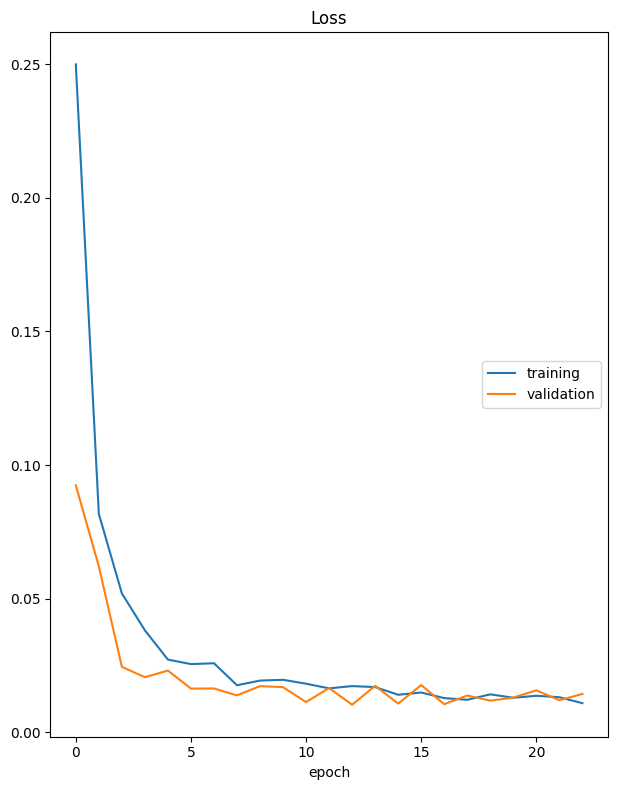

Loss
	training         	 (min:    0.011, max:    0.250, cur:    0.011)
	validation       	 (min:    0.010, max:    0.092, cur:    0.014)
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0101 - val_loss: 0.0143
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000208BA1C91C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 

In [13]:
# Compilar modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Separar set de validación
X_train_split, X_val, Y_train_split, Y_val = train_test_split(X_train, Y_train, test_size=0.15, random_state=42)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar modelo
model.fit(
    X_train_split, Y_train_split,
    validation_data=(X_val, Y_val),
    epochs=200,
    callbacks=[PlotLossesKeras(), early_stop],
    verbose=1
)

# Evaluación en test final
predictions_modelo3 = model.predict(X_test)
mae_modelo3 = mean_absolute_error(Y_test, predictions_modelo3)
mse_modelo3 = mean_squared_error(Y_test, predictions_modelo3)

print(f'\nEvaluación del modelo con Dropout y EarlyStopping:')
print(f'Error Absoluto Medio (MAE): {mae_modelo3:.4f}')
print(f'Error Cuadrático Medio (MSE): {mse_modelo3:.4f}')

**Análisis**

Este segmento de código tiene una red neuronal multicapa más robusta debido a que implementamos regularización como Dropout y EarlyStopping, con el fin de eviar sobreajsute y mejorar la capacidad de generalización. Se compone de tres capas ocultas con 256, 128 y 64 neuronas, todas con función de reactivación ReLU. Se aplicó un Droupout del 30% despues de las dos primeras capas ocultas. Se entrenó con 200 épocas con detección temprana si no se mejoraba la validación en 10 epocas consecutivas.

La red demostró una reducción en el error durante el entrenamiento como en validación, debido al control implementado con *EarlyStopping*. La pérdida en entrenamiento llegó hasta 0.011, y en validación se estabilizó en 0.014, lo cual indica un buen desempeño. A pesar de la mayor profundidad y del uso de técnicas de regularización, el modelo no logró superar los resultados obtenidos en el Punto 1, lo cual sugiere que la complejidad añadida no aportó una mejora sustancial para este dataset en particular.

Se obtuvo un MAE 0.0906 y MSE 0.0118, el modelo más complejo presenta mayor error.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

                                Modelo       MAE       MSE
0                               1 capa  0.040887  0.003133
1                            Multicapa  0.061690  0.006156
2  Multicapa + Dropout + EarlyStopping  0.090612  0.011810


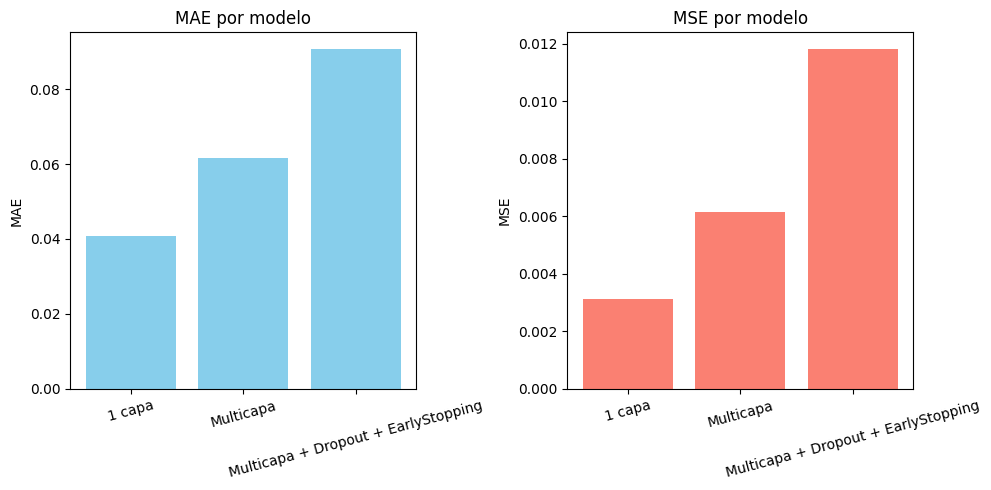

In [14]:
# Celda 4
resultados = pd.DataFrame({
    'Modelo': ['1 capa', 'Multicapa', 'Multicapa + Dropout + EarlyStopping'],
    'MAE': [mae_modelo1, mae_modelo2, mae_modelo3],
    'MSE': [mse_modelo1, mse_modelo2, mse_modelo3]
})
print(resultados)

# Gráfico de barras
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(resultados['Modelo'], resultados['MAE'], color='skyblue')
plt.title('MAE por modelo')
plt.xticks(rotation=15)
plt.ylabel('MAE')

plt.subplot(1, 2, 2)
plt.bar(resultados['Modelo'], resultados['MSE'], color='salmon')
plt.title('MSE por modelo')
plt.xticks(rotation=15)
plt.ylabel('MSE')

plt.tight_layout()
plt.show()

El modelo más simple resultó ser el más eficaz para este conjunto de datos, demostrando que en ciertos problemas de regresión, una arquitectura sencilla puede ser más precisa.
A mayor complejidad no siempre se da un mejor desempeño, por esta razón es necesario los ajustes y validar sobre el MAE y MSE. Se recomienda que la validación cruzada y monitoreo del sobreajuste mediante técnicas como early stopping.